#  Notebook 01 — Preprocessing & Exploratory Data Analysis
## Portal Pelaporan Tindak Kriminal Terpadu



## 0. Setup & Install Dependencies

In [28]:
# Install semua dependency yang dibutuhkan
import subprocess, sys

packages = [
    "pandas", "numpy", "matplotlib", "seaborn",
    "scikit-learn", "imbalanced-learn",
    "wordcloud", "PySastrawi",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("✅ Semua dependency terinstall")


✅ Semua dependency terinstall


## 1. Import Libraries & Load Data

In [29]:
import pandas as pd
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from pathlib import Path

warnings.filterwarnings('ignore')

# Style plot
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_palette("husl")

print("✅ Libraries imported")


✅ Libraries imported


In [30]:
# ── Load data kotor ──────────────────────────────────────────────
# Sesuaikan path jika perlu
DATA_DIR  = Path("../data")
INPUT_CSV = DATA_DIR / "dataset_kriminal_final.csv"
OUTPUT_CSV = DATA_DIR / "dataset_siap_training.csv"

df_raw = pd.read_csv(INPUT_CSV)
print(f"Shape     : {df_raw.shape}")
print(f"Kolom     : {df_raw.columns.tolist()}")
print()
df_raw.head(3)


Shape     : (2413, 10)
Kolom     : ['id', 'judul_berita', 'deskripsi_kejadian', 'lokasi_kejadian', 'waktu_kejadian', 'kategori_kejahatan', 'label_urgensi', 'sumber', 'url', 'scraped_at']



,id,judul_berita,deskripsi_kejadian,lokasi_kejadian,waktu_kejadian,kategori_kejahatan,label_urgensi,sumber,url,scraped_at
0,1,5 Fakta Alvi Pemutilasi Tiara Tak Terima Divon...,Perjalanan kasus mutilasi sadis terhadap Tiara...,Mojokerto,"Selasa, 28 Apr 2026 10:45",Pembunuhan,Tinggi,detik.com,https://www.detik.com/jatim/hukum-dan-kriminal...,2026-04-28 13:11:42
1,2,Cemburu Buta Berujung Petaka di Baleendah,Kasus pembunuhan akibat masalah asmara kembali...,Jelekong,"Selasa, 28 Apr 2026 09:30",Pembunuhan,Tinggi,detik.com,https://www.detik.com/jabar/hukum-dan-kriminal...,2026-04-28 13:11:48
2,3,Tak Puas Alvi Pemutilasi Tiara Meski Lolos Von...,"Alvi Maulana (24), terdakwa pembunuhan diserta...",Mojokerto,"Selasa, 28 Apr 2026 08:30",Pembunuhan,Tinggi,detik.com,https://www.detik.com/jatim/hukum-dan-kriminal...,2026-04-28 13:11:52


## 2. Data Understanding
Sebelum preprocessing, kita pahami dulu kondisi data mentah:
kualitas data, distribusi label, missing values, dan duplikat.


In [31]:
# ── Ringkasan dasar ──────────────────────────────────────────────
print("="*55)
print("  DATA UNDERSTANDING — DATASET KOTOR")
print("="*55)
print(f"  Total rows    : {len(df_raw):,}")
print(f"  Total kolom   : {len(df_raw.columns)}")
print()
print("  Missing Values:")
missing = df_raw.isnull().sum()
for col, n in missing[missing > 0].items():
    pct = n / len(df_raw) * 100
    print(f"    {col:<25}: {n:>5} ({pct:.1f}%)")

print()
print("  Distribusi label_urgensi (SEBELUM preprocessing):")
vc = df_raw['label_urgensi'].value_counts()
for lbl, n in vc.items():
    bar = '█' * (n // 30)
    print(f"    {lbl:<8}: {n:>5}  {bar}")

rasio = vc.min() / vc.max()
print(f"\n  Rasio min/max : {rasio:.2f}", "✅ Balanced" if rasio >= 0.6 else "⚠️  Imbalanced")


  DATA UNDERSTANDING — DATASET KOTOR
  Total rows    : 2,413
  Total kolom   : 10

  Missing Values:
    lokasi_kejadian          :  1125 (46.6%)

  Distribusi label_urgensi (SEBELUM preprocessing):
    Tinggi  :   981  ████████████████████████████████
    Sedang  :   947  ███████████████████████████████
    Rendah  :   485  ████████████████

  Rasio min/max : 0.49 ⚠️  Imbalanced


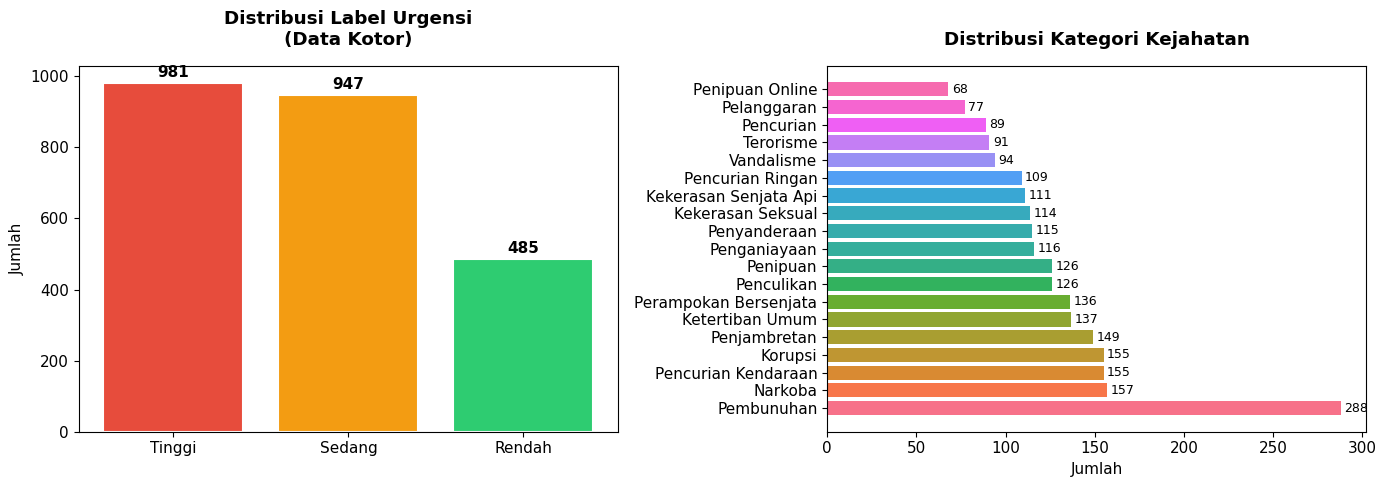

✅ Plot disimpan ke docs/01_distribusi_awal.png


In [32]:
# ── Visualisasi distribusi label awal ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart label
vc = df_raw['label_urgensi'].value_counts()
colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = axes[0].bar(vc.index, vc.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Label Urgensi\n(Data Kotor)', fontweight='bold', pad=15)
axes[0].set_ylabel('Jumlah')
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(val), ha='center', va='bottom', fontweight='bold')

# Bar chart kategori
kat = df_raw['kategori_kejahatan'].value_counts()
axes[1].barh(kat.index, kat.values, color=sns.color_palette("husl", len(kat)))
axes[1].set_title('Distribusi Kategori Kejahatan', fontweight='bold', pad=15)
axes[1].set_xlabel('Jumlah')
for i, val in enumerate(kat.values):
    axes[1].text(val + 2, i, str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/01_distribusi_awal.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot disimpan ke docs/01_distribusi_awal.png")


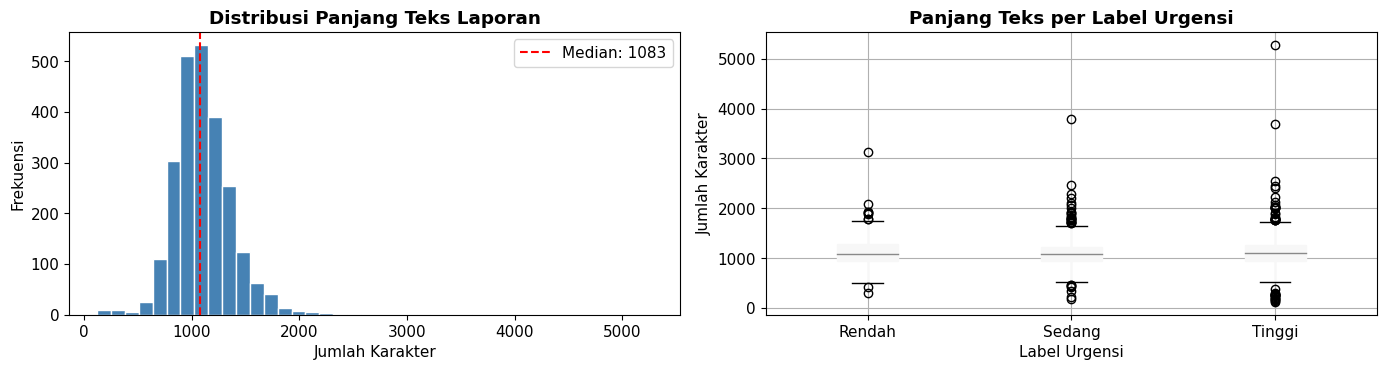

Statistik panjang teks:
count    2413.000000
mean     1110.151678
std       293.335943
min       123.000000
25%       940.000000
50%      1083.000000
75%      1253.000000
max      5282.000000


In [33]:
# ── Panjang teks ─────────────────────────────────────────────────
df_raw['panjang_teks'] = df_raw['deskripsi_kejadian'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram panjang teks keseluruhan
axes[0].hist(df_raw['panjang_teks'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Panjang Teks Laporan', fontweight='bold')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df_raw['panjang_teks'].median(), color='red',
                linestyle='--', label=f"Median: {df_raw['panjang_teks'].median():.0f}")
axes[0].legend()

# Boxplot per label
df_raw.boxplot(column='panjang_teks', by='label_urgensi', ax=axes[1],
               patch_artist=True)
axes[1].set_title('Panjang Teks per Label Urgensi', fontweight='bold')
axes[1].set_xlabel('Label Urgensi')
axes[1].set_ylabel('Jumlah Karakter')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../docs/02_panjang_teks.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Statistik panjang teks:")
print(df_raw['panjang_teks'].describe().to_string())


## 3. Data Preprocessing

### Konfigurasi Pipeline


In [34]:
# ── KAMUS NORMALISASI ────────────────────────────────────────────
KAMUS_INFORMAL = {
    "maling": "pencuri", "begal": "perampok", "copet": "pencopet",
    "bajingan": "pelaku", "penjahat": "pelaku", "bandit": "pelaku",
    "dibacok": "ditusuk", "dihajar": "dipukul", "digebuk": "dipukul",
    "dicolong": "dicuri", "diembat": "dicuri", "disikat": "dicuri",
    "ketangkep": "ditangkap", "kecokok": "ditangkap",
    "dibekuk": "ditangkap", "diringkus": "ditangkap",
    "kabur": "melarikan diri", "minggat": "melarikan diri",
    "tewas": "meninggal", "mati": "meninggal", "modar": "meninggal",
    "sekarat": "kritis",
    "sabu": "narkotika", "ganja": "narkotika",
    "ekstasi": "narkotika", "pil koplo": "narkotika",
    "ngelapor": "melaporkan", "ngadu": "melapor",
    "babak belur": "luka parah", "bonyok": "luka memar",
    "polda": "kepolisian daerah", "polres": "kepolisian resort",
    "polsek": "kepolisian sektor", "wna": "warga negara asing",
    "wni": "warga negara indonesia",
    "kpk": "komisi pemberantasan korupsi",
    "bnn": "badan narkotika nasional",
    "reskrim": "reserse kriminal",
    "gak": "tidak", "nggak": "tidak", "udah": "sudah",
    "emang": "memang", "yg": "yang", "dgn": "dengan",
    "utk": "untuk", "krn": "karena", "sdh": "sudah",
    "tsb": "tersebut", "tdk": "tidak",
}

# CATATAN: "tidak" sengaja TIDAK masuk stopwords
# karena mengubah makna urgensi: "tidak ada korban" ≠ "ada korban"
STOPWORDS_ID = {
    "dan", "di", "ke", "dari", "ini", "itu", "dengan",
    "untuk", "pada", "adalah", "dalam", "juga",
    "saat", "akan", "oleh", "ada", "karena", "sehingga", "namun",
    "tetapi", "atau", "jika", "maka", "setelah", "sebelum", "ketika",
    "agar", "bila", "seperti", "antara", "tersebut", "telah", "bisa",
    "dapat", "harus", "selain", "serta", "bahwa", "pun", "lagi",
    "atas", "bawah", "lebih", "cukup", "hanya", "masih",
    "belum", "sedang", "memang", "hingga", "sampai", "lalu",
    "kemudian", "hal", "para", "salah", "satu", "dua", "tiga",
    "pertama", "kedua", "ketiga", "mereka", "kami", "kita",
    "saya", "anda", "ia", "dia", "nya", "pagi", "siang", "malam",
    "hari", "minggu", "bulan", "tahun", "waktu", "tempat",
    "pria", "wanita", "orang", "seorang", "baik", "jelas",
}

KEYWORDS_URGENSI = {
    "Tinggi": [
        "bunuh", "pembunuhan", "mutilasi", "meninggal",
        "perkosa", "pemerkosaan", "kekerasan seksual",
        "rampok", "bersenjata", "senjata api", "tembak",
        "culik", "sandera", "bom", "teror", "ledakan",
        "tikam", "bacok", "tusuk", "luka berat",
    ],
    "Sedang": [
        "curi", "pencurian", "jambret", "copet",
        "aniaya", "penganiayaan", "pukul", "keroyok",
        "narkoba", "narkotika",
        "tipu", "penipuan", "investasi bodong",
        "korupsi", "suap", "gratifikasi",
    ],
    "Rendah": [
        "vandalisme", "coret", "grafiti",
        "perkelahian", "ribut", "bentrok",
        "pungli", "pungutan liar",
        "parkir liar", "gangguan",
        "penipuan online", "scam",
    ],
}

KEYWORDS_TINGGI = [
    "meninggal", "tewas", "korban jiwa", "nyawa",
    "dibunuh", "pembunuhan", "membunuh", "mutilasi",
    "ditusuk", "ditembak", "dibacok",
    "diperkosa", "pemerkosaan",
    "diculik", "penculikan", "disandera", "penyanderaan",
    "bom", "terorisme", "teroris",
    "senjata api", "pistol", "senapan",
]

KEYWORDS_SEDANG = [
    "dicuri", "pencurian", "dijambret", "dirampok",
    "dianiaya", "penganiayaan", "dipukuli", "dikeroyok",
    "narkoba", "narkotika", "sabu", "ganja",
    "penipuan", "menipu", "ditipu",
    "korupsi", "kpk", "ditangkap", "diringkus", "dibekuk",
]

print("✅ Konfigurasi preprocessing siap")
print(f"   Kamus informal  : {len(KAMUS_INFORMAL)} entri")
print(f"   Stopwords       : {len(STOPWORDS_ID)} kata")
print(f"   Keywords urgensi: {sum(len(v) for v in KEYWORDS_URGENSI.values())} total keyword")


✅ Konfigurasi preprocessing siap
   Kamus informal  : 49 entri
   Stopwords       : 85 kata
   Keywords urgensi: 48 total keyword


In [35]:
# ── FUNGSI PREPROCESSING ─────────────────────────────────────────
def normalisasi_informal(teks):
    teks = teks.lower()
    for informal, formal in KAMUS_INFORMAL.items():
        teks = re.sub(r'\b' + re.escape(informal) + r'\b', formal, teks)
    return teks

def bersihkan_teks(teks):
    if not teks or not isinstance(teks, str): return ""
    teks = re.sub(r'http\S+|www\S+', '', teks)
    teks = re.sub(r'\S+@\S+', '', teks)
    teks = re.sub(r'\b\d+\b', '', teks)
    teks = re.sub(r'[^\w\s]', ' ', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()
    return teks

def hapus_stopwords(teks):
    kata = teks.split()
    return ' '.join([k for k in kata if k not in STOPWORDS_ID and len(k) > 2])

def get_stemmer():
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    return StemmerFactory().create_stemmer()

def pipeline_preprocessing(teks, stemmer):
    if not teks or not isinstance(teks, str): return ""
    teks = normalisasi_informal(teks)
    teks = bersihkan_teks(teks)
    teks = hapus_stopwords(teks)
    teks = stemmer.stem(teks)
    return teks

def ekstrak_keywords(teks, label):
    teks_lower = teks.lower()
    found = []
    for kw in KEYWORDS_URGENSI.get(label, []):
        if kw in teks_lower: found.append(kw)
    for lbl, kws in KEYWORDS_URGENSI.items():
        if lbl != label:
            for kw in kws:
                if kw in teks_lower and kw not in found: found.append(kw)
    return ', '.join(found[:10])

def relabel(row):
    teks = str(row.get('deskripsi_kejadian', '')).lower()
    label_asal = row['label_urgensi']
    ada_tinggi = any(kw in teks for kw in KEYWORDS_TINGGI)
    ada_sedang = any(kw in teks for kw in KEYWORDS_SEDANG)
    if label_asal == 'Rendah':
        if ada_tinggi: return 'Tinggi'
        elif ada_sedang: return 'Sedang'
        return 'Rendah'
    elif label_asal == 'Sedang':
        if ada_tinggi: return 'Tinggi'
        return 'Sedang'
    return 'Tinggi'  # Tinggi tidak diturunkan

print("✅ Fungsi preprocessing terdefinisi")


✅ Fungsi preprocessing terdefinisi


### Step 2 — Hapus Duplikat & Data Tidak Valid

In [36]:
df = df_raw.copy()

# Fill missing
df['deskripsi_kejadian'] = df['deskripsi_kejadian'].fillna('')
df['lokasi_kejadian']    = df['lokasi_kejadian'].fillna('')
df['waktu_kejadian']     = df['waktu_kejadian'].fillna('')

sebelum = len(df)

# Hapus duplikat URL
dup_url = df.duplicated(subset=['url']).sum()
df = df.drop_duplicates(subset=['url'], keep='first')

# Hapus teks terlalu pendek (< 100 karakter — tidak informatif)
terlalu_pendek = (df['deskripsi_kejadian'].str.len() < 100).sum()
df = df[df['deskripsi_kejadian'].str.len() >= 100]
df = df.reset_index(drop=True)

print(f"Sebelum          : {sebelum:,} rows")
print(f"Duplikat URL     : -{dup_url}")
print(f"Teks terlalu pendek: -{terlalu_pendek}")
print(f"Sesudah          : {len(df):,} rows")

# Simpan teks original
df['deskripsi_original'] = df['deskripsi_kejadian'].copy()


Sebelum          : 2,413 rows
Duplikat URL     : -0
Teks terlalu pendek: -0
Sesudah          : 2,413 rows


### Step 3 — Preprocessing Teks

In [37]:
print("Loading stemmer Sastrawi...")
stemmer = get_stemmer()
print("✅ Stemmer siap\n")

print("Memproses teks (stemming ~3-5 menit)...")
total = len(df)
hasil = []

for i, teks in enumerate(df['deskripsi_kejadian']):
    hasil.append(pipeline_preprocessing(teks, stemmer))
    if (i + 1) % 200 == 0 or (i + 1) == total:
        print(f"  Progress: {i+1}/{total} ({(i+1)/total*100:.1f}%)", end='\r')

df['deskripsi_bersih'] = hasil
print(f"\n✅ Preprocessing selesai")

# Verifikasi sample
print("\nSample hasil preprocessing:")
print(f"  Original : {df['deskripsi_original'].iloc[0][:120]}")
print(f"  Bersih   : {df['deskripsi_bersih'].iloc[0][:120]}")


Loading stemmer Sastrawi...
✅ Stemmer siap

Memproses teks (stemming ~3-5 menit)...
  Progress: 2413/2413 (100.0%)
✅ Preprocessing selesai

Sample hasil preprocessing:
  Original : Perjalanan kasus mutilasi sadis terhadap Tiara Angelina Saraswati memasuki babak baru. Alvi Maulana, terdakwa pembunuhan
  Bersih   : jalan kasus mutilasi sadis hadap tiara angelina saraswati pasuk babak baru alvi maulana dakwa bunuh serta mutilasi hadap


### Step 4 — Ekstrak Keyword Highlights

In [38]:
df['keywords_highlight'] = df.apply(
    lambda row: ekstrak_keywords(row['deskripsi_original'], row['label_urgensi']), axis=1
)

ada_kw = (df['keywords_highlight'] != '').sum()
print(f"Coverage keywords : {ada_kw}/{len(df)} ({ada_kw/len(df)*100:.1f}%)")

# Top keywords
all_kw = []
for kw_str in df['keywords_highlight'].dropna():
    all_kw.extend([k.strip() for k in kw_str.split(',') if k.strip()])

top_kw = Counter(all_kw).most_common(15)
print("\nTop 15 keywords:")
for kw, n in top_kw:
    print(f"  {kw:<25}: {n}")


Coverage keywords : 2163/2413 (89.6%)

Top 15 keywords:
  pukul                    : 647
  curi                     : 462
  bunuh                    : 306
  pencurian                : 306
  pembunuhan               : 227
  meninggal                : 223
  narkoba                  : 196
  aniaya                   : 195
  bersenjata               : 169
  penipuan                 : 167
  penganiayaan             : 163
  jambret                  : 148
  korupsi                  : 147
  rampok                   : 137
  mutilasi                 : 136


### Step 5 — Relabeling Otomatis

In [39]:
df['label_asal']    = df['label_urgensi'].copy()
df['label_urgensi'] = df.apply(relabel, axis=1)

diubah = (df['label_asal'] != df['label_urgensi']).sum()
print(f"Total direlabel : {diubah} artikel ({diubah/len(df)*100:.1f}%)")
print()
print("Detail perubahan:")
for asal in ['Tinggi', 'Sedang', 'Rendah']:
    for baru in ['Tinggi', 'Sedang', 'Rendah']:
        if asal != baru:
            n = ((df['label_asal'] == asal) & (df['label_urgensi'] == baru)).sum()
            if n > 0:
                print(f"  {asal} → {baru} : {n}")

print()
print("Distribusi setelah relabeling:")
vc = df['label_urgensi'].value_counts()
print(vc.to_string())
rasio = vc.min() / vc.max()
print(f"\nRasio min/max : {rasio:.2f}", "✅" if rasio >= 0.6 else "⚠️  Imbalanced → perlu SMOTE")


Total direlabel : 464 artikel (19.2%)

Detail perubahan:
  Sedang → Tinggi : 149
  Rendah → Tinggi : 127
  Rendah → Sedang : 188

Distribusi setelah relabeling:
label_urgensi
Tinggi    1257
Sedang     986
Rendah     170

Rasio min/max : 0.14 ⚠️  Imbalanced → perlu SMOTE


### Step 6 — SMOTE Balancing

> **Catatan penting:** SMOTE pada data teks menghasilkan "teks sintetis" berupa  
> bag-of-words dari inverse TF-IDF, bukan kalimat natural. Data ini **hanya digunakan  
> untuk training**, bukan untuk test/evaluasi. Test set wajib dari data real (`is_synthetic=No`).


In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

label_map     = {'Tinggi': 0, 'Sedang': 1, 'Rendah': 2}
label_map_inv = {v: k for k, v in label_map.items()}

vectorizer   = TfidfVectorizer(max_features=5000, min_df=2)
X            = vectorizer.fit_transform(df['deskripsi_bersih'].fillna(''))
y            = df['label_urgensi'].map(label_map).values

print(f"Distribusi sebelum SMOTE:")
for lbl, idx in label_map.items():
    print(f"  {lbl}: {(y == idx).sum()}")

smote        = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

n_original   = len(df)
n_synthetic  = len(y_res) - n_original

print(f"\nHasil SMOTE:")
print(f"  Data original  : {n_original:,}")
print(f"  Data sintetis  : {n_synthetic:,}")
print(f"  Total          : {len(y_res):,}")


Distribusi sebelum SMOTE:
  Tinggi: 1257
  Sedang: 986
  Rendah: 170

Hasil SMOTE:
  Data original  : 2,413
  Data sintetis  : 1,358
  Total          : 3,771


In [41]:
# ── Buat DataFrame hasil SMOTE ──────────────────────────────────
synthetic_texts = vectorizer.inverse_transform(X_res[n_original:])
df['is_synthetic'] = 'No'

synthetic_rows = []
for i, (words, label_idx) in enumerate(zip(synthetic_texts, y_res[n_original:])):
    label    = label_map_inv[label_idx]
    teks_syn = ' '.join(words)
    synthetic_rows.append({
        'id': f"syn_{i+1}", 'judul_berita': f"[SYNTHETIC] {label} #{i+1}",
        'deskripsi_kejadian': teks_syn, 'lokasi_kejadian': '',
        'waktu_kejadian': '', 'kategori_kejahatan': 'SYNTHETIC',
        'label_urgensi': label, 'label_asal': label,
        'sumber': 'SMOTE', 'url': '', 'scraped_at': '',
        'deskripsi_original': teks_syn, 'deskripsi_bersih': teks_syn,
        'keywords_highlight': '', 'is_synthetic': 'Yes',
    })

df_synthetic = pd.DataFrame(synthetic_rows)
df_final     = pd.concat([df, df_synthetic], ignore_index=True)
df_final['id'] = range(1, len(df_final) + 1)

print("Distribusi final setelah SMOTE:")
vc_final = df_final['label_urgensi'].value_counts()
for lbl, n in vc_final.items():
    bar = '█' * (n // 50)
    pct = n / len(df_final) * 100
    print(f"  {lbl:<8}: {n:>5} ({pct:.1f}%)  {bar}")

print(f"\nRasio min/max : {vc_final.min()/vc_final.max():.2f} ✅")


Distribusi final setelah SMOTE:
  Tinggi  :  1257 (33.3%)  █████████████████████████
  Sedang  :  1257 (33.3%)  █████████████████████████
  Rendah  :  1257 (33.3%)  █████████████████████████

Rasio min/max : 1.00 ✅


In [42]:
# ── Simpan dataset final ─────────────────────────────────────────
KOLOM_OUTPUT = [
    'id', 'judul_berita', 'deskripsi_kejadian',
    'lokasi_kejadian', 'waktu_kejadian',
    'kategori_kejahatan', 'label_urgensi', 'label_asal',
    'sumber', 'url', 'scraped_at',
    'deskripsi_original', 'deskripsi_bersih',
    'keywords_highlight', 'is_synthetic',
]
for col in KOLOM_OUTPUT:
    if col not in df_final.columns:
        df_final[col] = ''

df_final[KOLOM_OUTPUT].to_csv(OUTPUT_CSV, index=False, encoding='utf-8')
print(f"✅ Disimpan ke: {OUTPUT_CSV}")
print(f"   Total rows : {len(df_final):,}")


✅ Disimpan ke: ..\data\dataset_siap_training.csv
   Total rows : 3,771


## 4. Exploratory Data Analysis (EDA)
Analisis mendalam pada dataset yang sudah dipreprocessing.


In [43]:
df_eda = pd.read_csv(OUTPUT_CSV)
df_real = df_eda[df_eda['is_synthetic'] == 'No'].copy()  # hanya data real untuk EDA

print(f"Dataset final   : {len(df_eda):,} rows")
print(f"Data real       : {len(df_real):,} rows")
print(f"Data sintetis   : {(df_eda['is_synthetic']=='Yes').sum():,} rows")


Dataset final   : 3,771 rows
Data real       : 2,413 rows
Data sintetis   : 1,358 rows


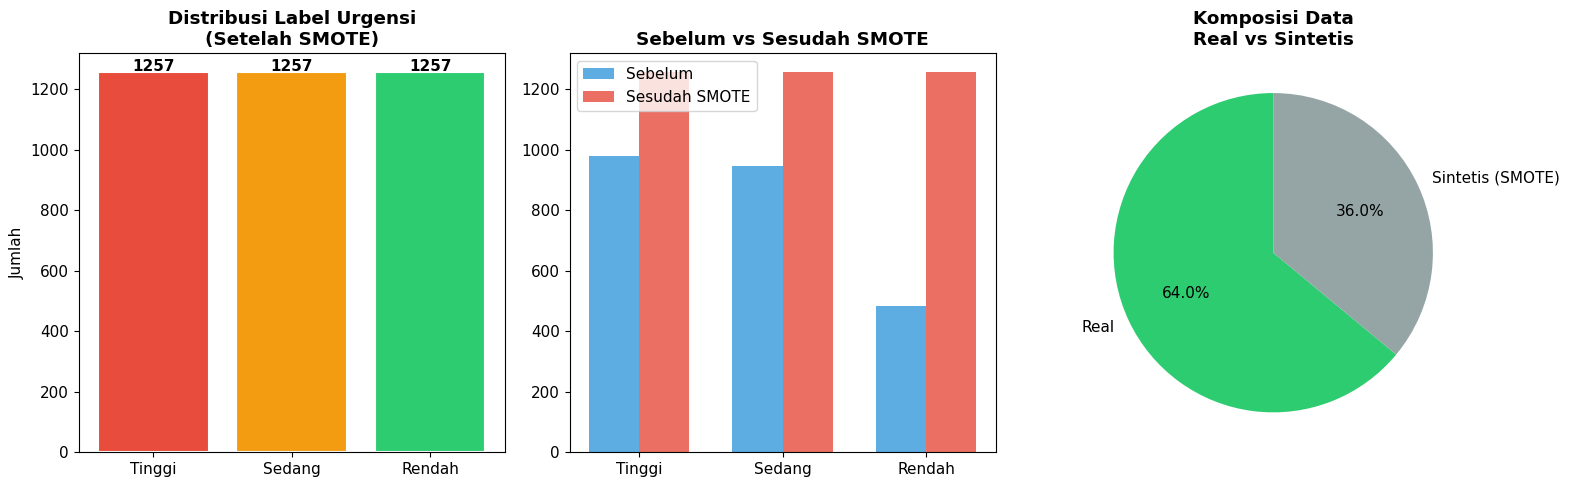

In [44]:
# ── EDA 1: Distribusi final ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Label distribution (final)
vc = df_eda['label_urgensi'].value_counts()
colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = axes[0].bar(vc.index, vc.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Label Urgensi\n(Setelah SMOTE)', fontweight='bold')
axes[0].set_ylabel('Jumlah')
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontweight='bold')

# Perbandingan sebelum vs sesudah
labels = ['Tinggi', 'Sedang', 'Rendah']
sebelum_vals = [df_raw['label_urgensi'].value_counts().get(l, 0) for l in labels]
sesudah_vals = [vc.get(l, 0) for l in labels]
x = np.arange(len(labels))
w = 0.35
axes[1].bar(x - w/2, sebelum_vals, w, label='Sebelum', color='#3498db', alpha=0.8)
axes[1].bar(x + w/2, sesudah_vals, w, label='Sesudah SMOTE', color='#e74c3c', alpha=0.8)
axes[1].set_title('Sebelum vs Sesudah SMOTE', fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].legend()

# Synthetic vs Real
pie_data = [len(df_real), (df_eda['is_synthetic']=='Yes').sum()]
axes[2].pie(pie_data, labels=['Real', 'Sintetis (SMOTE)'],
            colors=['#2ecc71', '#95a5a6'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Komposisi Data\nReal vs Sintetis', fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/03_distribusi_final.png', dpi=150, bbox_inches='tight')
plt.show()


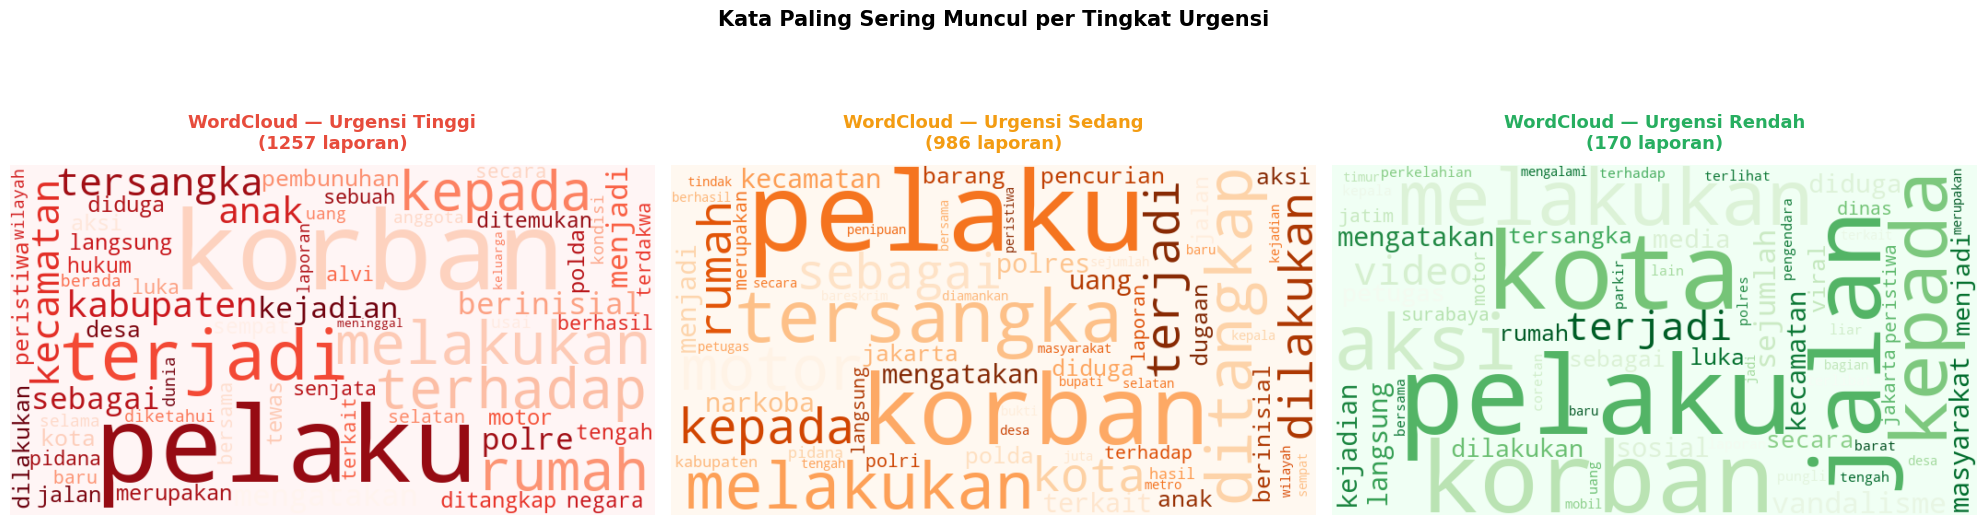

✅ WordCloud disimpan ke docs/04_wordcloud.png


In [45]:
# ── EDA 2: WordCloud per label ──────────────────────────────────
# PENTING: pakai deskripsi_ORIGINAL bukan deskripsi_bersih
# Stemming mengubah "pelaku"→"laku", "berkata"→"kata" yang merusak readability
from wordcloud import WordCloud
import re

# Stopwords diperluas khusus untuk wordcloud
# (lebih agresif dari stopwords model karena tujuannya visual, bukan prediksi)
STOPWORDS_VIZ = {
    # Stopwords dasar
    "yang", "dan", "di", "ke", "dari", "ini", "itu", "dengan",
    "untuk", "pada", "adalah", "dalam", "tidak", "juga", "sudah",
    "saat", "akan", "oleh", "ada", "karena", "sehingga", "namun",
    "tetapi", "atau", "jika", "maka", "setelah", "sebelum", "ketika",
    "agar", "bila", "seperti", "antara", "tersebut", "telah", "bisa",
    "dapat", "harus", "selain", "serta", "bahwa", "pun", "lagi",
    "atas", "bawah", "lebih", "sangat", "cukup", "hanya", "masih",
    "belum", "sedang", "memang", "hingga", "sampai", "lalu",
    "kemudian", "hal", "para", "salah", "satu", "dua", "tiga",
    "pertama", "kedua", "ketiga", "mereka", "kami", "kita",
    "saya", "anda", "ia", "dia", "nya", "pagi", "siang", "malam",
    "hari", "minggu", "bulan", "tahun", "waktu", "tempat",
    "pria", "wanita", "orang", "seorang", "baik", "jelas",
    # Kata jurnalistik yang tidak informatif
    "ujar", "kata", "ungkap", "sebut", "jelas", "terang",
    "lanjut", "tambah", "tutur", "ucap",
    # Kata sangat umum yang muncul di semua label
    "warga", "polisi", "kasus", "pihak", "lokasi", "sekitar",
    "satu", "dua", "tiga", "beberapa", "banyak", "jumlah",
    "senin", "selasa", "rabu", "kamis", "jumat", "sabtu", "minggu",
    "januari", "februari", "maret", "april", "mei", "juni",
    "juli", "agustus", "september", "oktober", "november", "desember",
    "wib", "wita", "wit", "pukul",
    # Kata pendek tidak bermakna
    "pun", "itu", "ini", "ada", "tak", "kini", "sini", "sana",
}

def bersihkan_untuk_viz(teks):
    """Cleaning ringan untuk wordcloud — tanpa stemming"""
    if not isinstance(teks, str): return ""
    teks = re.sub(r'http\S+|www\S+', '', teks)
    teks = re.sub(r'\b\d+\b', '', teks)
    teks = re.sub(r'[^\w\s]', ' ', teks)
    teks = teks.lower()
    kata = teks.split()
    kata = [k for k in kata if k not in STOPWORDS_VIZ and len(k) > 3]
    return ' '.join(kata)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
label_configs = {
    'Tinggi': {'cmap': 'Reds',    'bg': '#fff5f5'},
    'Sedang': {'cmap': 'Oranges', 'bg': '#fff8f0'},
    'Rendah': {'cmap': 'Greens',  'bg': '#f0fff4'},
}

for ax, (label, cfg) in zip(axes, label_configs.items()):
    # Pakai deskripsi_original bukan deskripsi_bersih
    teks_list = df_real[df_real['label_urgensi'] == label]['deskripsi_original'].dropna()
    teks_bersih = [bersihkan_untuk_viz(t) for t in teks_list]
    teks_gabung = ' '.join(teks_bersih)

    if teks_gabung.strip():
        wc = WordCloud(
            width=700, height=380,
            background_color=cfg['bg'],
            colormap=cfg['cmap'],
            max_words=60,
            min_font_size=10,
            max_font_size=120,
            prefer_horizontal=0.8,
            collocations=False,   # hindari duplikasi frasa
            stopwords=STOPWORDS_VIZ,
        ).generate(teks_gabung)
        ax.imshow(wc, interpolation='bilinear')

    ax.axis('off')
    n = len(teks_list)
    badge_color = {'Tinggi': '#e74c3c', 'Sedang': '#f39c12', 'Rendah': '#27ae60'}[label]
    ax.set_title(f'WordCloud — Urgensi {label}\n({n} laporan)',
                 fontweight='bold', fontsize=13, color=badge_color, pad=12)

plt.suptitle('Kata Paling Sering Muncul per Tingkat Urgensi',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../docs/04_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ WordCloud disimpan ke docs/04_wordcloud.png")


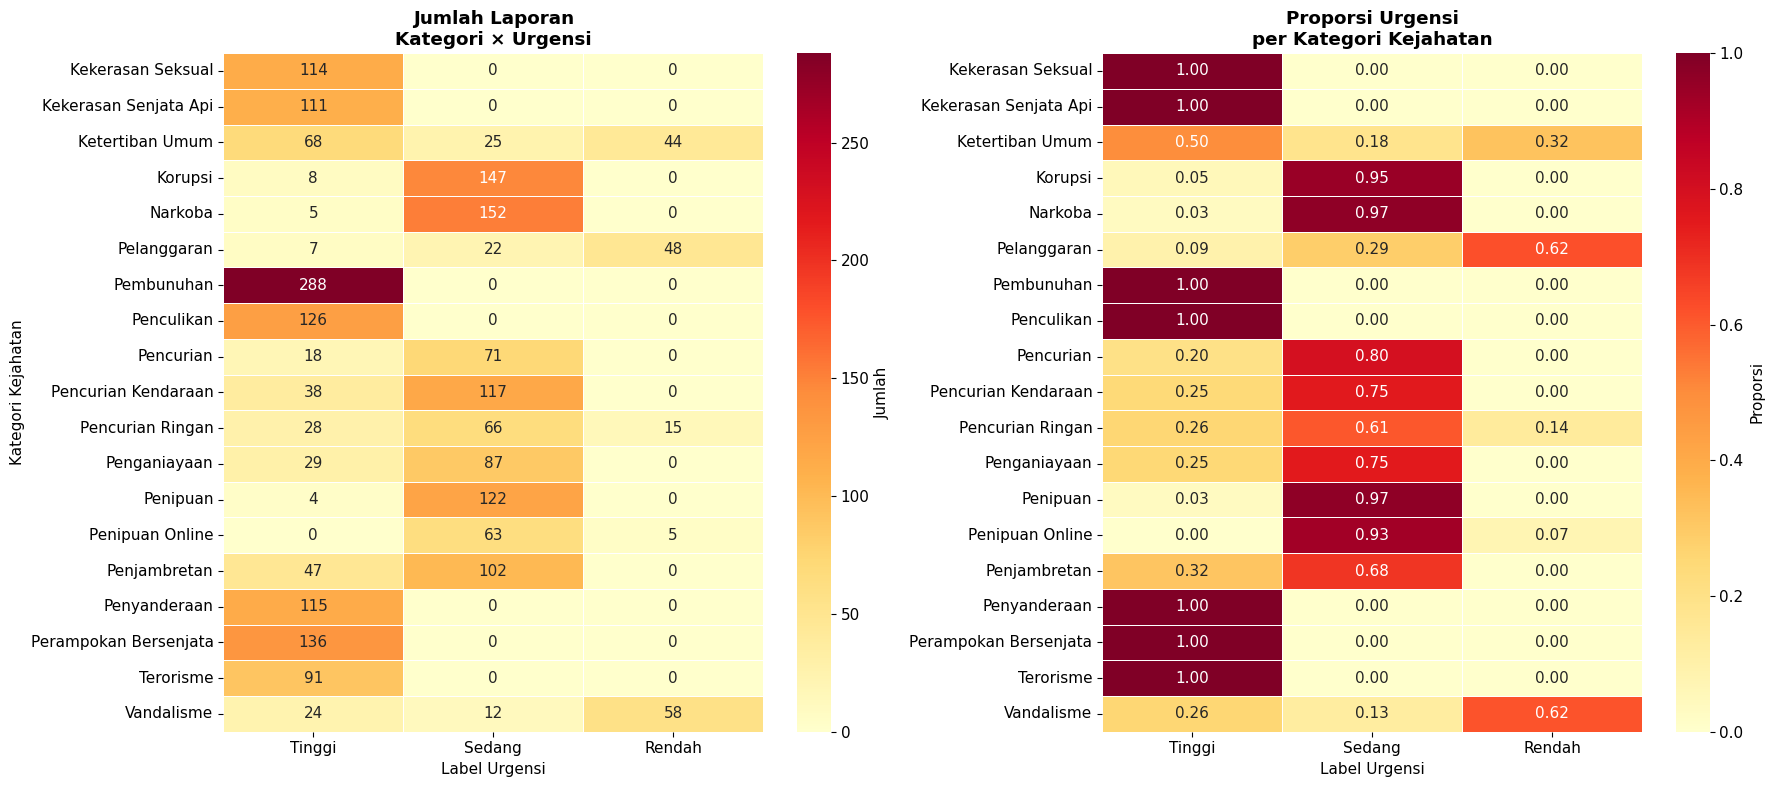

In [46]:
# ── EDA 3: Heatmap korelasi label vs kategori ────────────────────
pivot = df_real.groupby(['kategori_kejahatan', 'label_urgensi']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=['Tinggi', 'Sedang', 'Rendah'], fill_value=0)

# Normalisasi per baris
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Jumlah'})
axes[0].set_title('Jumlah Laporan\nKategori × Urgensi', fontweight='bold')
axes[0].set_xlabel('Label Urgensi'); axes[0].set_ylabel('Kategori Kejahatan')

sns.heatmap(pivot_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Proporsi'})
axes[1].set_title('Proporsi Urgensi\nper Kategori Kejahatan', fontweight='bold')
axes[1].set_xlabel('Label Urgensi'); axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../docs/05_heatmap_kategori_urgensi.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Clustering — Unsupervised Topic Discovery

Clustering digunakan untuk menemukan pola topik kejahatan secara alami  
tanpa menggunakan label. Hasilnya ditampilkan di dashboard kepolisian  
sebagai "Peta Topik Kejahatan".

**Metode:** K-Means pada representasi TF-IDF  
**Tujuan:** Validasi apakah cluster yang terbentuk konsisten dengan kategori/label yang ada


In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Pakai data real saja untuk clustering
teks_cluster = df_real['deskripsi_bersih'].fillna('').tolist()

vec = TfidfVectorizer(max_features=3000, min_df=3, ngram_range=(1, 2))
X_cluster = vec.fit_transform(teks_cluster)
print(f"Matrix TF-IDF shape: {X_cluster.shape}")


Matrix TF-IDF shape: (2413, 3000)


  K=2: inertia=2260, silhouette=0.012
  K=3: inertia=2227, silhouette=0.021
  K=4: inertia=2204, silhouette=0.023
  K=5: inertia=2191, silhouette=0.023
  K=6: inertia=2177, silhouette=0.022
  K=7: inertia=2164, silhouette=0.019
  K=8: inertia=2153, silhouette=0.020
  K=9: inertia=2146, silhouette=0.021
  K=10: inertia=2135, silhouette=0.021


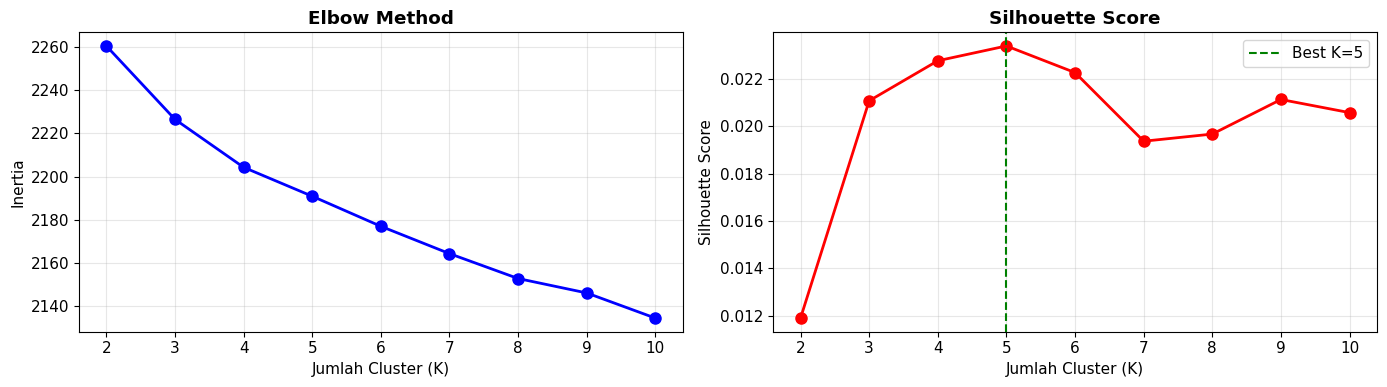


✅ K optimal berdasarkan silhouette: K=5


In [48]:
# ── Elbow method + Silhouette untuk cari K optimal ───────────────
inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, km.labels_, sample_size=500))
    print(f"  K={k}: inertia={km.inertia_:.0f}, silhouette={silhouettes[-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

best_k = K_range[np.argmax(silhouettes)]
axes[1].axvline(best_k, color='green', linestyle='--', label=f'Best K={best_k}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/06_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ K optimal berdasarkan silhouette: K={best_k}")


In [49]:
# ── Training K-Means dengan K optimal ────────────────────────────
K_OPTIMAL = best_k  # atau set manual, misal: K_OPTIMAL = 5

km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
km_final.fit(X_cluster)
df_real = df_real.copy()
df_real['cluster_id'] = km_final.labels_

print(f"K-Means selesai dengan K={K_OPTIMAL}")
print()
print("Distribusi per cluster:")
print(df_real['cluster_id'].value_counts().sort_index().to_string())


K-Means selesai dengan K=5

Distribusi per cluster:
cluster_id
0     92
1    102
2    946
3    300
4    973


In [50]:
# ── Top keywords per cluster ──────────────────────────────────────
feature_names = vec.get_feature_names_out()
order_centroids = km_final.cluster_centers_.argsort()[:, ::-1]

print("Top 10 kata per cluster:")
print("="*60)
cluster_labels_manual = {}
for i in range(K_OPTIMAL):
    top_words = [feature_names[j] for j in order_centroids[i, :10]]
    print(f"\nCluster {i}: {', '.join(top_words)}")
    # Distribusi label urgensi di cluster ini
    dist = df_real[df_real['cluster_id'] == i]['label_urgensi'].value_counts()
    print(f"  Urgensi: {dict(dist)}")
    # Distribusi kategori
    kat_dist = df_real[df_real['cluster_id'] == i]['kategori_kejahatan'].value_counts().head(3)
    print(f"  Kategori top 3: {dict(kat_dist)}")


Top 10 kata per cluster:

Cluster 0: dakwa, alvi, sidang, hakim, tuntut, mojokerto, adil, tiara, jaksa, bunuh
  Urgensi: {'Tinggi': 76, 'Sedang': 12, 'Rendah': 4}
  Kategori top 3: {'Pembunuhan': 56, 'Penculikan': 9, 'Narkoba': 4}

Cluster 1: korupsi, komisi berantas, berantas korupsi, berantas, komisi, bupati, ott, tangkap, budi, yang
  Urgensi: {'Sedang': 97, 'Tinggi': 5}
  Kategori top 3: {'Korupsi': 101, 'Terorisme': 1}

Cluster 2: yang, polisi, laku, sangka, kasus, daerah, tidak, kata, anak, narkotika
  Urgensi: {'Sedang': 496, 'Tinggi': 337, 'Rendah': 113}
  Kategori top 3: {'Narkoba': 141, 'Penipuan': 111, 'Pelanggaran': 63}

Cluster 3: tembak, yang, tinggal, serang, kelompok, negara, iran, trump, presiden, jadi
  Urgensi: {'Tinggi': 281, 'Sedang': 11, 'Rendah': 8}
  Kategori top 3: {'Kekerasan Senjata Api': 94, 'Penyanderaan': 62, 'Terorisme': 51}

Cluster 4: korban, laku, yang, polisi, jadi, motor, rumah, curi, tangkap, warga
  Urgensi: {'Tinggi': 558, 'Sedang': 370, 'Rendah':

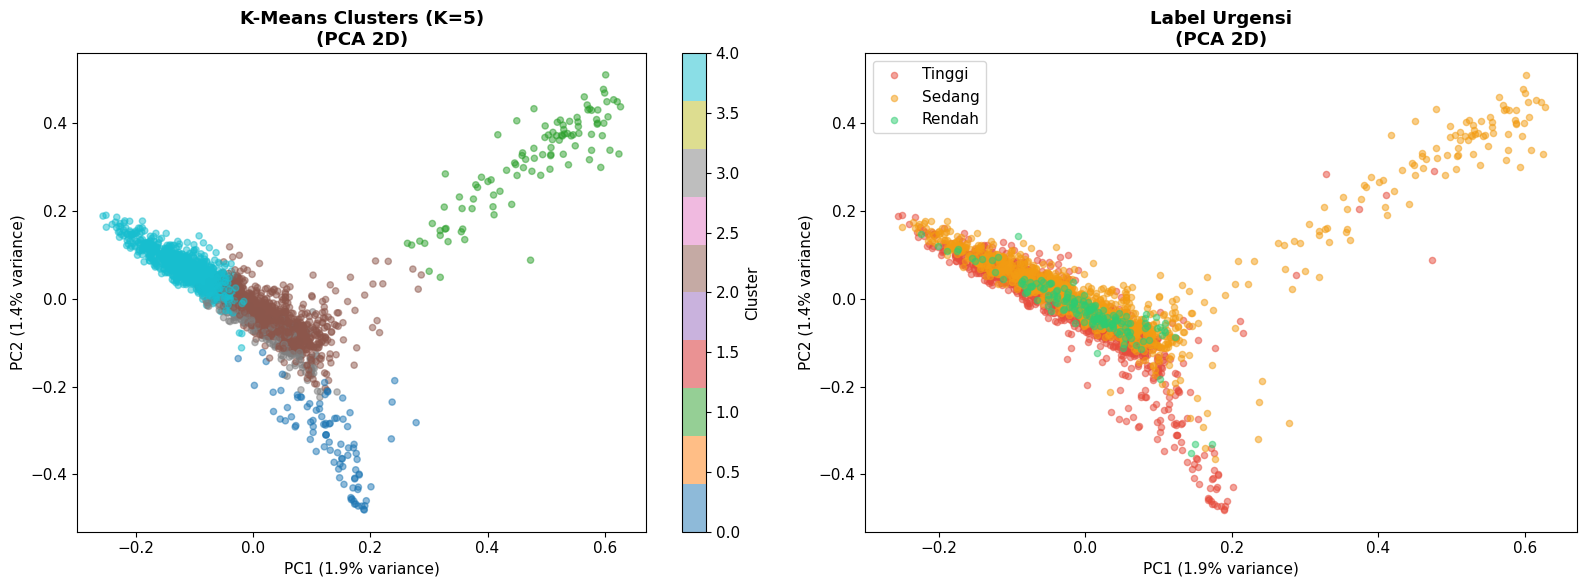

Explained variance PCA: 3.4%


In [51]:
# ── Visualisasi cluster dengan PCA 2D ────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster.toarray())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colored by cluster
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                            c=df_real['cluster_id'], cmap='tab10',
                            alpha=0.5, s=20)
axes[0].set_title(f'K-Means Clusters (K={K_OPTIMAL})\n(PCA 2D)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Colored by label urgensi
color_map = {'Tinggi': '#e74c3c', 'Sedang': '#f39c12', 'Rendah': '#2ecc71'}
for label, color in color_map.items():
    mask = df_real['label_urgensi'] == label
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=label, alpha=0.5, s=20)
axes[1].set_title('Label Urgensi\n(PCA 2D)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/07_cluster_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Explained variance PCA: {sum(pca.explained_variance_ratio_)*100:.1f}%")


In [52]:
# ── Simpan hasil cluster ke dataset final ───────────────────────
# Update cluster_id di df_final
cluster_mapping = dict(zip(df_real.index, df_real['cluster_id']))
df_final_updated = pd.read_csv(OUTPUT_CSV)

# Hanya update baris yang real (index dari df_real)
df_final_updated['cluster_id'] = None
for idx, cluster in cluster_mapping.items():
    if idx < len(df_final_updated):
        df_final_updated.at[idx, 'cluster_id'] = int(cluster)

df_final_updated.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Cluster ID disimpan ke {OUTPUT_CSV}")
print(f"   Rows dengan cluster_id: {df_final_updated['cluster_id'].notna().sum()}")


✅ Cluster ID disimpan ke ..\data\dataset_siap_training.csv
   Rows dengan cluster_id: 2413


## 6. Ringkasan & Kesimpulan Preprocessing

### Perubahan Data
| Tahap | Jumlah Rows |
|-------|-------------|
| Data mentah | 2,413 |
| Setelah cleaning | ~2,400 |
| Setelah relabeling | ~2,400 (label berubah) |
| Setelah SMOTE | 3,771 |

### Keputusan Desain Penting
1. **`tidak` tidak dihapus dari stopwords** — kata ini mengubah makna urgensi secara signifikan
2. **Stemming Sastrawi** — mengurangi dimensi fitur TF-IDF, meningkatkan generalisasi model
3. **SMOTE pada TF-IDF** — menghasilkan data sintetis berupa bag-of-words, bukan kalimat natural. Digunakan hanya untuk training, bukan evaluasi
4. **Test set harus dari `is_synthetic=No`** — evaluasi model harus pada data real

### Fitur untuk Training Model
- **X (input)**: `deskripsi_bersih` → TF-IDF vector
- **y (target)**: `label_urgensi` (Tinggi / Sedang / Rendah)
- **Metadata**: `keywords_highlight`, `cluster_id` untuk dashboard
